In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, r2_score

In [16]:
df = pd.read_csv("./datasets/salary.csv")
print(df.shape)
print(df.isnull().sum())
df.head()

(330, 2)
YearsExperience    0
Salary             0
dtype: int64


,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [17]:
x = df["YearsExperience"].values.reshape(-1, 1)
y = df["Salary"]

In [41]:
poly = PolynomialFeatures(degree=3)  # degree: 차수
x_poly = poly.fit_transform(x)

print (x_poly)  # degree=3 적용 시 [1, x, x², x³] 4개 col로 변환된다.

[[1.00000000e+00 1.20000000e+00 1.44000000e+00 1.72800000e+00]
 [1.00000000e+00 1.40000000e+00 1.96000000e+00 2.74400000e+00]
 [1.00000000e+00 1.60000000e+00 2.56000000e+00 4.09600000e+00]
 ...
 [1.00000000e+00 9.39757411e+00 8.83143991e+01 8.29941110e+02]
 [1.00000000e+00 9.83876242e+00 9.68012460e+01 9.52404462e+02]
 [1.00000000e+00 1.04945460e+01 1.10135495e+02 1.15582201e+03]]


In [42]:
x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.2, random_state=42)

In [43]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
y_pred = model.predict(x_test)

print(f"MAE : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"R²  : {r2_score(y_test, y_pred):.4f}")

MAE : 5,306
R²  : 0.9444


In [45]:
sample = poly.transform([[7]])
print(f"predicted salary: {model.predict(sample)[0]:,.0f}")

predicted salary: 93,525


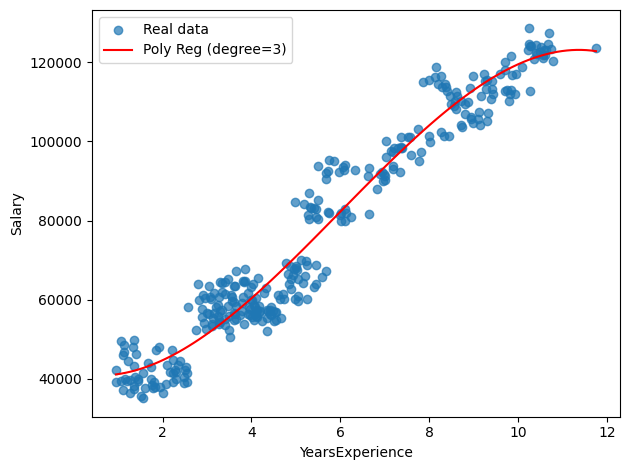

In [46]:
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)

# Linear
linear = LinearRegression().fit(x_train, y_train)

# Polynomial
x_poly_range = poly.transform(x_range)
y_poly_line = model.predict(x_poly_range)

plt.scatter(x, y, alpha=0.7, label="Real data")
plt.plot(x_range, y_poly_line, color="red", label=f"Poly Reg (degree=3)")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.legend()
plt.tight_layout()
plt.show()

--- degree에 따른 Overfitting 예제 ---

MAE : 4,817
R²  : 0.9539
predicted salary: 97,341


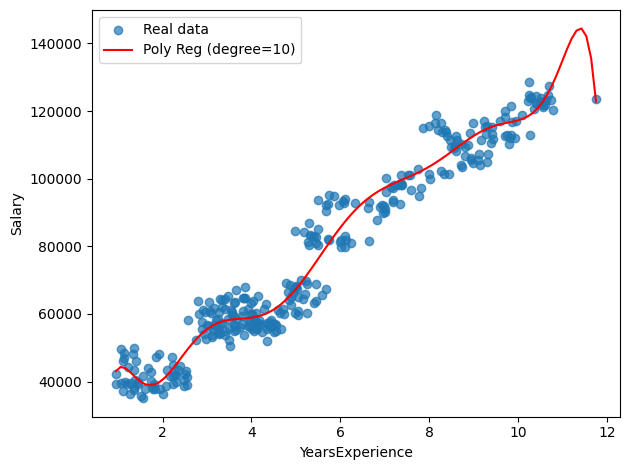

In [ ]:
poly = PolynomialFeatures(degree=10)  # degree: 차수
x_poly = poly.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print(f"MAE : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"R²  : {r2_score(y_test, y_pred):.4f}")
sample = poly.transform([[7]])
print(f"predicted salary: {model.predict(sample)[0]:,.0f}")
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)

# Linear
linear = LinearRegression().fit(x_train, y_train)

# Polynomial
x_poly_range = poly.transform(x_range)
y_poly_line = model.predict(x_poly_range)

plt.scatter(x, y, alpha=0.7, label="Real data")
plt.plot(x_range, y_poly_line, color="red", label=f"Poly Reg (degree=10)")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.legend()
plt.tight_layout()
plt.show()

# degree가 너무 높다면 그만큼 고차항을 더 많이 가지므로,
# 학습 데이터에 더 가깝게 학습된다. 따라서 Overfitting이 발생한다.

---

In [ ]:
# degree를 올릴수록 train R²는 계속 증가하지만, Overfitting으로 인해 test R²가 오히려 감소한다.

x_train_raw, x_test_raw, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

for d in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:
    poly = PolynomialFeatures(degree=d)
    X_tr = poly.fit_transform(x_train_raw)
    X_te = poly.transform(x_test_raw)
    r2 = r2_score(y_test, LinearRegression().fit(X_tr, y_train).predict(X_te))
    print(f"degree={d}  R²: {r2:.4f}")

degree=1  R²: 0.9410
degree=2  R²: 0.9406
degree=3  R²: 0.9444
degree=4  R²: 0.9444
degree=5  R²: 0.9451
degree=6  R²: 0.9449
degree=7  R²: 0.9506
degree=8  R²: 0.9504
degree=9  R²: 0.9496
degree=10  R²: 0.9539
degree=11  R²: 0.9521
degree=12  R²: 0.9497
degree=13  R²: 0.9493
degree=14  R²: 0.9441
degree=15  R²: 0.9411
